#### Ice and Water Storage Anomalies: Computing GRACE(-FO) basin averages and associated uncertainties from the JPL-Mascon data using gridded mask

written by: Felix Landerer (landerer@jpl.nasa.gov) and Munish Sikka (munish.sikka@jpl.nasa.gov)

Version 1.0 [May-2026]

In [1]:
import sys
import os
if 'google.colab' in sys.modules:
    print("Running in Colab. Preparing NASA-GRACE/GRACE-Analysis-Tutorials environment...")
    
    # 1. Install system libraries quietly
    !apt-get install -y libgdal-dev libproj-dev proj-data proj-bin libgeos-dev > /dev/null 2>&1
    
    # 2. Install Python packages while pinning fsspec to keep Colab happy
    # This prevents the red error message
    !pip install -q \
        fsspec==2025.3.0 \
        cartopy \
        geopandas \
        netcdf4 \
        h5netcdf \
        statsmodels \
        s3fs
    
    # 3. Clone the repository
    repo_url = "https://github.com/NASA-GRACE/GRACE-Analysis-Tutorials.git"
    repo_dir = "GRACE-Analysis-Tutorials"
    
    if not os.path.exists(repo_dir):
        # Clone if it's the first time running this session
        !git clone {repo_url}
    else:
        # If folder exists, just pull the latest code to ensure it's up to date
        print("Repository already exists. Syncing latest changes...")
        %cd {repo_dir}
        !git pull origin main
    
    # 4. Path Configuration
    # Ensure we are actually inside the directory
    if os.getcwd() != f"/content/{repo_dir}":
        os.chdir(f"/content/{repo_dir}")
     
    # 5. Add the current directory to the system path as a backup
    if f"/content/{repo_dir}" not in sys.path:
        sys.path.append(f"/content/{repo_dir}")
        
    print("Setup complete! The environment is stable and ready.")
else:
    print("Running locally.")

Running locally.


In [2]:
import time
from netCDF4 import Dataset, date2index , num2date
from datetime import datetime, date

import xarray as xr
import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt
from matplotlib.path import Path
import warnings
import os

import sys
import os.path
import subprocess
import netCDF4
import math
import csv

#import s3fs
import copy
import json, copy
from pandas import DataFrame
from osgeo import gdal, ogr, osr
import re
import calendar
import grace_user_functions as grace_func
import header_text
import trend_fit as fit_py

Step 1: Load GRACE/GRACE-FO data and basin masks
1.1 Read a basin mask from netcdf file

In [3]:
file_access_type = 'local'
#file_access_type = 'cloud'
ShortName_mass = 'TELLUS_GRAC-GRFO_MASCON_CRI_GRID_RL06.1_V3' # PO.DAAC's 'short name' is an identifier for the dataset
grace_filename ='GRCTellus.JPL.200204_202510.GLO.RL06.3M.MSCNv04CRI.nc' #edit to the filename user wants to read

start_date = "2002-04-01"
end_date = "none" #yyyy-mm-dd (eg. "2024-09-30") or set as none to read from filename upto the last available month
# segment to extract end date from mascon filename
if end_date == 'none':
    date_range = re.search(r"(\d{6})_(\d{6})",grace_filename)
    if not date_range:
        raise ValueError("Date range not found in filename")
    end_date_str = date_range.group(2)
    year = int(end_date_str[:4])
    month = int(end_date_str[4:])
    day = calendar.monthrange(year,month)[1]
    end_date = datetime(year,month,day).strftime("%Y-%m-%d")
print(end_date)    

# download the GRACE mascon dataset and use the absolute path in next line where it is kept in local file system
full_filename = 'GRACE_RESOURCES/' + grace_filename
mask_filename = 'GRACE_RESOURCES/' + 'jpl_msc3d_gris_ais_masks.nc'

mask_datset = xr.open_dataset((mask_filename))
mask_str = 'antarctica' #antarctica #greenland

sig_calc = 2       # 1 = calculate standard error of model to data for trend uncertainty
                    # 2 = use only measurement/leakage error to calculate trend uncertainty
GRN_GIAerr = 21    # GIA error for Greenland in Gt/yr
ANT_GIAerr = 39    # GIA error for Antarctica in Gt/yr

if mask_str == 'greenland':
    mask = mask_datset["gris_mask_jplmsc3deg"]# for greenland
    GIA_error = GRN_GIAerr
elif mask_str == 'antarctica':
    mask = mask_datset["ais_mask_jplmsc3deg"]# for antarctica
    GIA_error = ANT_GIAerr
else:
    print('Invalid mask string for this tutorial')

mask = mask.to_numpy()

# Specify the file path greenland_mass_200204_202407
start_date_obj = datetime.strptime(start_date,"%Y-%m-%d")
start_yearmonth = start_date_obj.strftime("%Y%m")
end_date_obj = datetime.strptime(end_date,"%Y-%m-%d")
end_yearmonth = end_date_obj.strftime("%Y%m")
output_filename = f"{mask_str}_mass_{start_yearmonth}_{end_yearmonth}.txt"

2025-10-31


1.2 Read mascon dataset

In [4]:
if file_access_type.lower() == 'local':
    print("Reading GRACE mascon dataset from local disk")
    try:
        dataset = xr.open_dataset((full_filename))
    except FileNotFoundError:
        print('Error: The file does not exist.')
elif file_access_type.lower() == "cloud":
    print("Reading GRACE mascon dataset from PODAAC Cloud")
    import s3fs
    dataset=grace_func.read_grace_dataset(ShortName_mass,grace_filename)	
else:
    print("Unknown file access type.")

Reading GRACE mascon dataset from local disk


1.3 Take a look at the dataset contents that were just loaded:

In [5]:
dataset

<xarray.Dataset> Size: 2GB
Dimensions:        (time: 250, lat: 360, lon: 720, bounds: 2)
Coordinates:
  * time           (time) datetime64[ns] 2kB 2002-04-17T12:00:00 ... 2025-10-...
  * lat            (lat) float64 3kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * lon            (lon) float64 6kB 0.25 0.75 1.25 1.75 ... 358.8 359.2 359.8
Dimensions without coordinates: bounds
Data variables:
    lwe_thickness  (time, lat, lon) float64 518MB ...
    uncertainty    (time, lat, lon) float64 518MB ...
    lat_bounds     (lat, bounds) float64 6kB ...
    lon_bounds     (lon, bounds) float64 12kB ...
    time_bounds    (time, bounds) datetime64[ns] 4kB ...
    land_mask      (lat, lon) float64 2MB ...
    scale_factor   (lat, lon) float64 2MB ...
    mascon_ID      (lat, lon) float64 2MB ...
    GAD            (time, lat, lon) float64 518MB ...
Attributes: (12/53)
    Conventions:                   CF-1.6, ACDD-1.3, ISO 8601
    Metadata_Conventions:          Unidata Dataset Discovery v1.0
    standard_name_vocabulary:      NetCDF Climate and Forecast (CF) Metadata ...
    title:                         JPL GRACE and GRACE-FO MASCON RL06.3Mv04 CRI
    summary:                       Monthly gravity solutions from GRACE and G...
    keywords:                      Solid Earth, Geodetics/Gravity, Gravity, l...
    ...                            ...
    C_30_substitution:             TN-14; Loomis et al., 2019, Geophys. Res. ...
    user_note_1:                   The accelerometer on the GRACE-B spacecraf...
    user_note_2:                   The accelerometer on the GRACE-D spacecraf...
    journal_reference:             Watkins, M. M., D. N. Wiese, D.-N. Yuan, C...
    CRI_filter_journal_reference:  Wiese, D. N., F. W. Landerer, and M. M. Wa...
    date_created:                  2026-01-06T12:01:45Z

1.4 Assign variables to compute water-equivalent heights:

In [6]:
lwe_thickness_subset = dataset["lwe_thickness"].sel(
    time=slice(start_date, end_date)).values
tdim, ydim, xdim = lwe_thickness_subset.shape

sig_lwe = dataset["uncertainty"].sel(
    time=slice(start_date, end_date)).values

lwe_thickness_subset = lwe_thickness_subset - lwe_thickness_subset[0,:,:]
lwe_thickness_subset = lwe_thickness_subset/100.0; #convert to m

sig_lwe = dataset["uncertainty"].sel(
    time=slice(start_date, end_date)).values
sig_lwe = sig_lwe/100.0 #convert to m


In [7]:
lat_vector = dataset.lat[:].copy()
lon_vector = dataset.lon[:].copy()
time_subset = dataset["time"].sel(
    time=slice(start_date, end_date)).values

1.4.1 Compute weighted area for this region_mask

In [8]:
mask,mask_A,mask_N = grace_func.drainage_basin_call(mask)

Using user defined mask: 360x720


Step 2: Calculate mean over selected region

In [9]:
# Create a weight mask where mask == 0 is set to 0, otherwise it's mask_A
effective_weights = np.where(mask == 0, 0, mask_A)
# Compute the sum across the spatial axes (1 and 2) in one go
regional_timeseries = np.sum(lwe_thickness_subset * effective_weights, axis=(1, 2))
regional_timeseries = regional_timeseries * 1000 / 1e12 #convert from g to Gigatonnes

Step 3: plot basin-mean

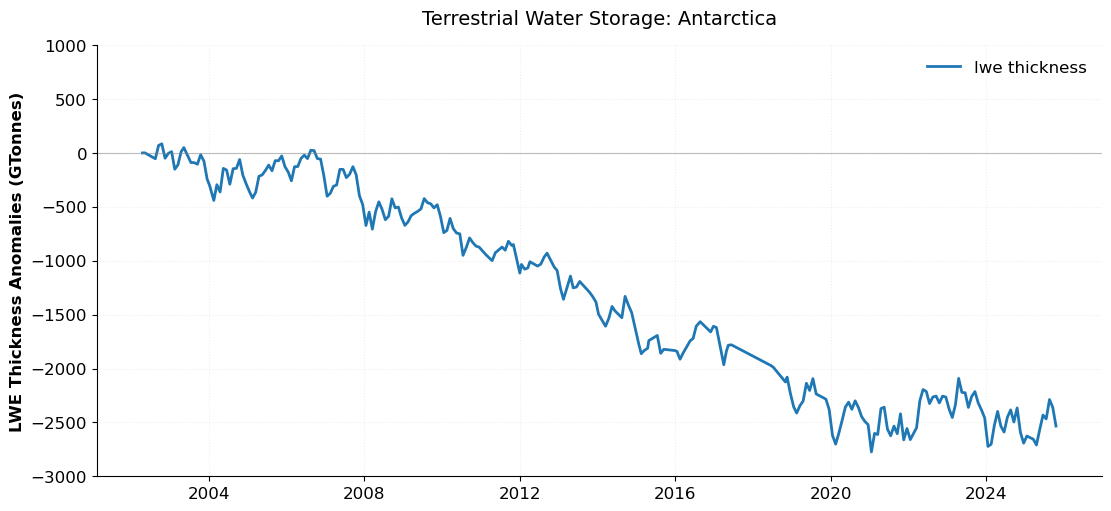

In [10]:
if mask_str == 'greenland':
    ymin = -6500
    ymax = 1000
elif mask_str == 'antarctica': 
    ymin = -3000
    ymax = 1000


timesteps = dataset["time"].sel(
    time=slice(start_date, end_date)).values
plot_title_str = 'Terrestrial Water Storage: ' + mask_str.capitalize()

# plot monthly timeseries (#ref: https://unidata.github.io/python-training/workshop/Time_Series/basic-time-series-plotting/)
xmin = timesteps[0]
xmax = timesteps[-1]
yticks = np.arange(ymin, ymax+1,2)

plt.rc('font', size=12)
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
# Specify how our lines should look
ax.plot(timesteps, regional_timeseries, color='tab:blue', label='lwe thickness',lw=2)
ax.axhline(y=0.0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

ax.set_ylabel('LWE Thickness Anomalies (GTonnes)', fontweight='bold')
ax.set_title(plot_title_str, fontsize=14, pad=15)
#ax.legend(loc='upper left');
ax.set_ylim([ymin, ymax])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2, linestyle=':')
ax.legend(loc='best', frameon=False)
fig.savefig(f"{mask_str}_lineplot.png",dpi=300)


In [11]:
timesteps_temp = [np.datetime64(i) for i in timesteps]
timesteps_datetime = pd.to_datetime(timesteps_temp)
date_str_list = [str(i.date()) for i in timesteps_datetime]
#print(date_str_list)
date_obj_list = [datetime.strptime(date_str,"%Y-%m-%d") for date_str in date_str_list]
timesteps_yearfrac = [grace_func.toYearFraction(date_obj) for date_obj in date_obj_list]

Step 4: Uncertainty Estimate over the Region of Interest

Source: https://grace.jpl.nasa.gov/data/get-data/jpl_global_mascons/
For the JPL Mascons, measurement uncertainties are provided on a 0.5 degree grid in latitude and longitude for each monthly grid. Importantly, the uncertainties provided are the uncertainty values for EACH independent mascon, which are roughly 300km in spatial extent. Thus, there are only 4,551 independent estimates of uncertainty represented for each monthly grid over entire globe. This needs to be taken into account when computing the uncertainty of basin means.

The mascon IDs for points in our regional analysis in this tutorial are determined using file containing mascon IDs.

A detailed description of the uncertainty derivation is found in Wiese, Landerer and Watkins (2016). https://agupubs.onlinelibrary.wiley.com/doi/full/10.1002/2016WR019344

In [12]:
#read the grid of mascon IDs from the mascon dataset
mascon_ID= dataset["mascon_ID"]
mscID=mascon_ID.to_numpy()
msc_type = 'full'; 

4.1 Recompute weighted area for this region_mask using full mascon blocks

In [13]:
mask,mask_A,mask_N = grace_func.drainage_basin_call(mask)
mask[mask>0] = 1

# rerun with binary [0,1] mask:
mask,mask_A,mask_N = grace_func.drainage_basin_call(mask)

Using user defined mask: 360x720
Using user defined mask: 360x720


In [14]:
w = np.unique(mask * mscID)
mask = np.isin(mscID,w).astype(int)

# rerun with this mask:
mask,mask_A,mask_N = grace_func.drainage_basin_call(mask)

Using user defined mask: 360x720


These gridded uncertainties are not the uncertainties associated with a single 0.5 degree pixel (which would be much higher!). 

To derive the scaled uncertainty estimates, we scale the formal covariance matrix over the ocean to match the error we see when comparing the GRACE/GRACE-FO data to in-situ ocean bottom pressure data. 

Over land, the formal uncertainty is scaled to roughly match uncertainty estimates that we derive using methods described in Wahr et al., (2006). 

The provided estimates of uncertainty are conservative. Since we implement a Kalman filter in our JPL-mascon solution process to link adjacent months together temporally, monthly solutions both at the very beginning and end of the time series have slightly larger uncertainties compared to monthly solutions in the middle of the time series. This also means that as the time series is extended with newer observations, the uncertainty estimates of recent months will change (typically: become smaller) as more data are added, until a floor is reached. Error estimates typically stabelize approx. 6 months away from the time series boundaries.

In [15]:
# find uncertainty values within the basin mask:
sig_lwe_ma , maA = grace_func.compute_regional_uncertainty(sig_lwe, mask_A, mscID) 

# RSS (Root Sum of Squares) for total regional error
bsn_sig = (np.sqrt(np.sum(np.square(sig_lwe_ma),axis=1)))

#convert units from g to Gigatonnes
bsn_sig = bsn_sig * 1000 / 1e12 

In [16]:
lower_bound = regional_timeseries - bsn_sig
upper_bound = regional_timeseries + bsn_sig

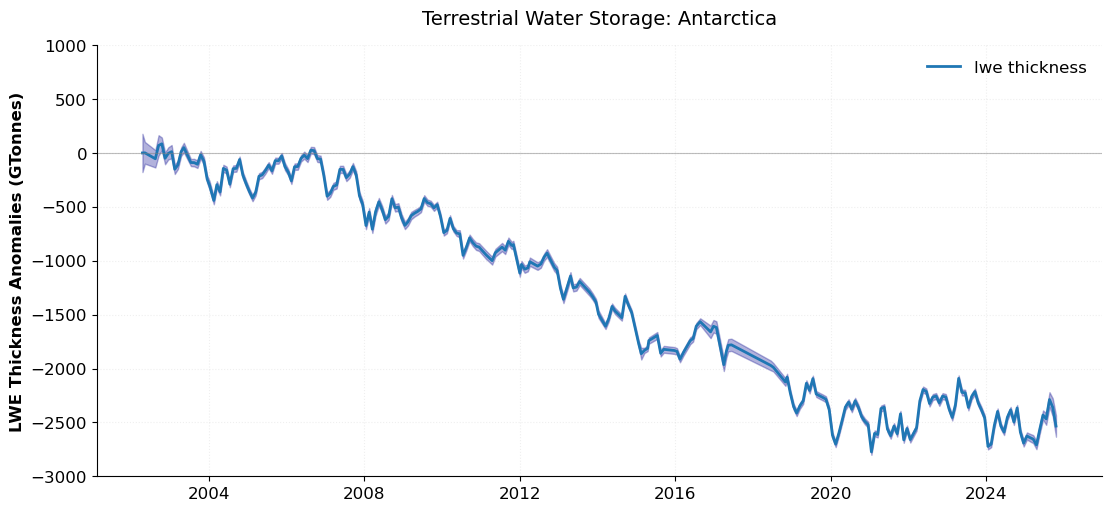

In [17]:
# plot monthly timeseries (#ref: https://unidata.github.io/python-training/workshop/Time_Series/basic-time-series-plotting/)
plt.rc('font', size=12)
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
# Specify how our lines should look
region_color='darkblue'
ax.plot(timesteps, regional_timeseries, color='tab:blue', label='lwe thickness',lw=2)
ax.fill_between(timesteps, lower_bound, upper_bound, alpha=0.3, edgecolor=region_color, facecolor=region_color)

ax.axhline(y=0.0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_ylabel('LWE Thickness Anomalies (GTonnes)', fontweight='bold')
ax.set_title(plot_title_str, fontsize=14, pad=15)
ax.set_ylim([ymin, ymax])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2, linestyle=':')
ax.legend(loc='best', frameon=False)


4.2 Trend calculation

In [18]:
freq = [1, 2, 365.25/161, 365.25/1362.7]
poly_deg = 1
exclude_trend = 0 # do not exclude trend here
timesteps_np = np.array(timesteps_yearfrac)

# function provided by Kevin Gaastra
model,sds,unused = fit_py.fit_tsin(timesteps_np, regional_timeseries,sig=bsn_sig, poly_deg=poly_deg, freq=freq, offsets=[], return_amp_phase=False, return_param_unc=True, chi2_cor=True, S2_G_GFO_shift=1)

trend = np.round(model[-2],2)
stddev = np.round(abs(sds[-2]*2),2)

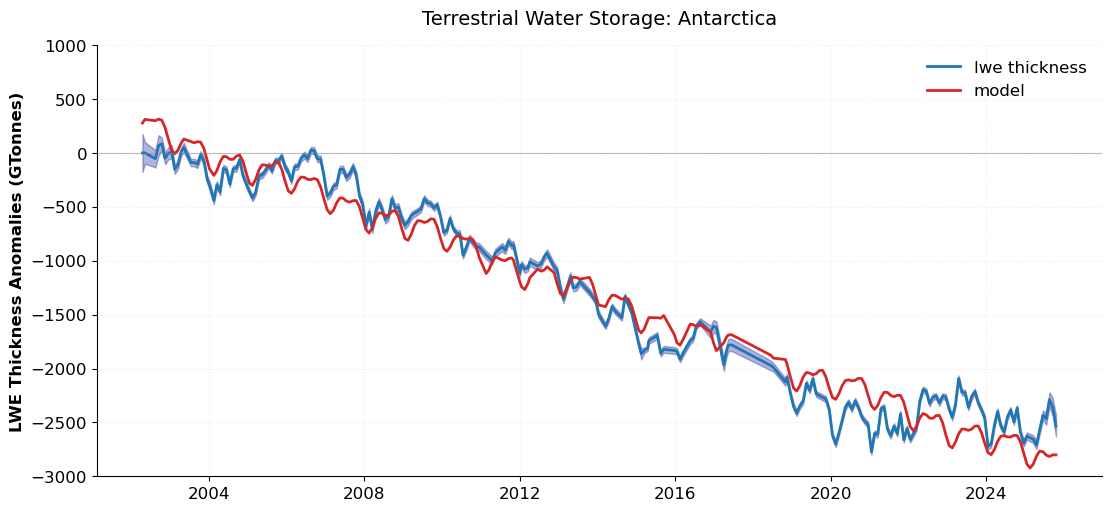

In [19]:
# create fitted timeseries and plot it along with original lwe_thickness for comparison
get_model = fit_py.get_tsin(model, timesteps_np,poly_deg,exclude_trend, freq, offsets=[], is_amp_phase=False, S2_G_GFO_shift=1)

# plot monthly timeseries (#ref: https://unidata.github.io/python-training/workshop/Time_Series/basic-time-series-plotting/)
plt.rc('font', size=12)
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
# Specify how our lines should look
region_color='darkblue'
ax.plot(timesteps, regional_timeseries, color='tab:blue', label='lwe thickness',lw=2)
ax.plot(timesteps, get_model, color='tab:red', label='model',lw=2)

ax.fill_between(timesteps, lower_bound, upper_bound, alpha=0.3, edgecolor=region_color, facecolor=region_color)

ax.axhline(y=0.0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_ylabel('LWE Thickness Anomalies (GTonnes)', fontweight='bold')
ax.set_title(plot_title_str, fontsize=14, pad=15)
ax.set_ylim([ymin, ymax])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2, linestyle=':')
ax.legend(loc='best', frameon=False)

In [20]:
if sig_calc == 1:
    slope_sig = np.sqrt(trend**2 + GIA_error**2)
elif sig_calc == 2:
    Xerr = np.sqrt(np.sum((timesteps_yearfrac - np.mean(timesteps_yearfrac))**2))
    slope_sig = np.sqrt((np.sqrt(np.sum(bsn_sig**2)/(bsn_sig.shape[0]-2))/Xerr)**2 + GIA_error**2)
slope_sig = np.round(slope_sig,2)

4.3 Write the output into txt file

In [21]:
# Prepare the data and the header to be written into txt file
end_year = end_date_obj.year
end_month = end_date_obj.month

formatted_month = f"{end_month:02}"
formatted_year = str(end_year)
formatted_date = f"{formatted_month}/{formatted_year}"

lines_of_strings = header_text.header_data(formatted_date,mask_str,trend,slope_sig)
# Ensure vectors are the same length
assert len(timesteps_yearfrac) == len(bsn_sig) == len(regional_timeseries), "Vectors must be of the same length"

try:
    if (len(timesteps_yearfrac) == len(bsn_sig) == len(regional_timeseries)):
        # Combine the vectors into a tab-delimited string
        combined_vectors = np.column_stack((timesteps_yearfrac, regional_timeseries,bsn_sig))
except Exception as e:
    print(f"An error occurred while combining vectors: {e}")

In [22]:
# Write the combined text and data to the file
with open(output_filename, 'w') as file:
    for line in lines_of_strings:
        file.write(line + "\n")
    # Write the vectors
    for i in range(len(timesteps_yearfrac)):
        file.write(f"{timesteps_yearfrac[i]:.2f}   {regional_timeseries[i]:>8.2f}   {bsn_sig[i]:>8.2f}\n")

print(f"Data has been written to {output_filename}")

Data has been written to antarctica_mass_200204_202510.txt
